<a href="https://colab.research.google.com/github/promckkon/MK2DimCNN/blob/main/AHSPSO%20with%200db%20in%20CW%20Data%20260512.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:

# =========================================================
# Cell 1: 環境配置與套件載入 (Environment & Setup)
# =========================================================
import os
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore') # 隱藏 Pandas FutureWarning 等

# 自動檢查並修復 CatBoost 與 NumPy 版本衝突
try:
    import catboost
    import numpy as np
    if catboost.__version__ != '1.2.7' or np.__version__ >= '2.0.0':
        raise ImportError
except:
    print("正在安裝穩定版環境 (NumPy 1.26.4 & CatBoost 1.2.7)...")
    get_ipython().system('pip install -q "numpy==1.26.4" "catboost==1.2.7" "scipy" "scikit-learn" "seaborn" "matplotlib"')
    print("--- 安裝完成！請點擊上方選單「執行階段」->「重新啟動執行階段」，然後再次執行此單元格 ---")

import scipy.io
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mutual_info_score
from sklearn.manifold import TSNE
from sklearn.utils import resample
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, entropy

import datetime
import random
import itertools # 🌟 [修改點 3] 加入 itertools，用來跑 6x6 矩陣的排列組合

print("✅ 所有套件與高級特徵計算工具載入完成，準備就緒！")

✅ 所有套件與高級特徵計算工具載入完成，準備就緒！


In [3]:
# =========================================================
# Cell 2: .mat 讀取、動態視窗切割與資料平衡 (完美對齊版)
# =========================================================
MAT_FOLDER_PATH = "/content/drive/MyDrive/TRIAX_with_NOISE/TRIAX_Dataset"
df_list = []

print("1. 遍歷讀取 .mat 檔案...")
for root, dirs, files in os.walk(MAT_FOLDER_PATH, topdown=False):
    for file_name in files:
        if file_name.endswith('.mat'):
            path = os.path.join(root, file_name)
            mat = scipy.io.loadmat(path)
            key_name = list(mat.keys())[3]
            df_temp = pd.DataFrame({'DE_data': np.ravel(mat.get(key_name)), 'fault': file_name[:-4]})
            df_list.append(df_temp)

df = pd.concat(df_list, ignore_index=True)

# 動態計算視窗
TARGET_ROWS = 2000
fault_types = df['fault'].unique()
win_len = int((len(df) / len(fault_types)) / (TARGET_ROWS / len(fault_types)))
stride = int(win_len * 0.7)

print(f"2. 滑動視窗提取特徵 (WINDOW: {win_len}, STRIDE: {stride})...")
X_raw_list, stats_list, y_list = [], [], []

for f in fault_types:
    fault_data = df[df['fault'] == f]['DE_data'].values.astype(float)
    num_windows = (len(fault_data) - win_len) // stride + 1
    for i in range(num_windows):
        window = fault_data[i*stride : i*stride + win_len]
        X_raw_list.append(window.reshape(-1, 1)) # 給 CNN 的 Raw Data
        y_list.append(f)
        rms = np.sqrt(np.mean(np.square(window)))
        mean_abs = np.mean(np.abs(window))
        stats_list.append([
            np.mean(window), np.std(window), rms, np.max(window), np.min(window),
            skew(window), kurtosis(window),
            rms / mean_abs if mean_abs != 0 else 0, np.max(window) / rms if rms != 0 else 0
        ])

# 資料平衡
temp_df = pd.DataFrame({'X_raw': X_raw_list, 'stats': stats_list, 'fault': y_list})
TARGET_BALANCED_ROWS = 1570
samples_per_class = TARGET_BALANCED_ROWS // len(fault_types)

print("3. 執行資料平衡 (Resample)...")
resampled_data = [resample(temp_df[temp_df['fault'] == f], replace=(len(temp_df[temp_df['fault'] == f]) < samples_per_class),
                           n_samples=samples_per_class, random_state=42) for f in fault_types]

balanced_df = pd.concat(resampled_data).sample(frac=1, random_state=42).reset_index(drop=True)

# 最終特徵陣列
X_raw_balanced = np.stack(balanced_df['X_raw'].values)
X_stat_balanced = np.stack(balanced_df['stats'].values)
y_label = balanced_df['fault'].values

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_label)
y_categorical = to_categorical(y_encoded)

print(f"✅ 資料處理完成！總樣本數: {len(balanced_df)}")

1. 遍歷讀取 .mat 檔案...
2. 滑動視窗提取特徵 (WINDOW: 552, STRIDE: 386)...
3. 執行資料平衡 (Resample)...
✅ 資料處理完成！總樣本數: 1568


1. 訓練 MK-DCNN 並提取深度特徵...
2. 執行 t-SNE 降維與特徵融合...
✅ 雙路徑特徵融合完成！CatBoost 最終輸入維度: (1568, 4)
3. 繪製特徵分佈 t-SNE 對比圖...


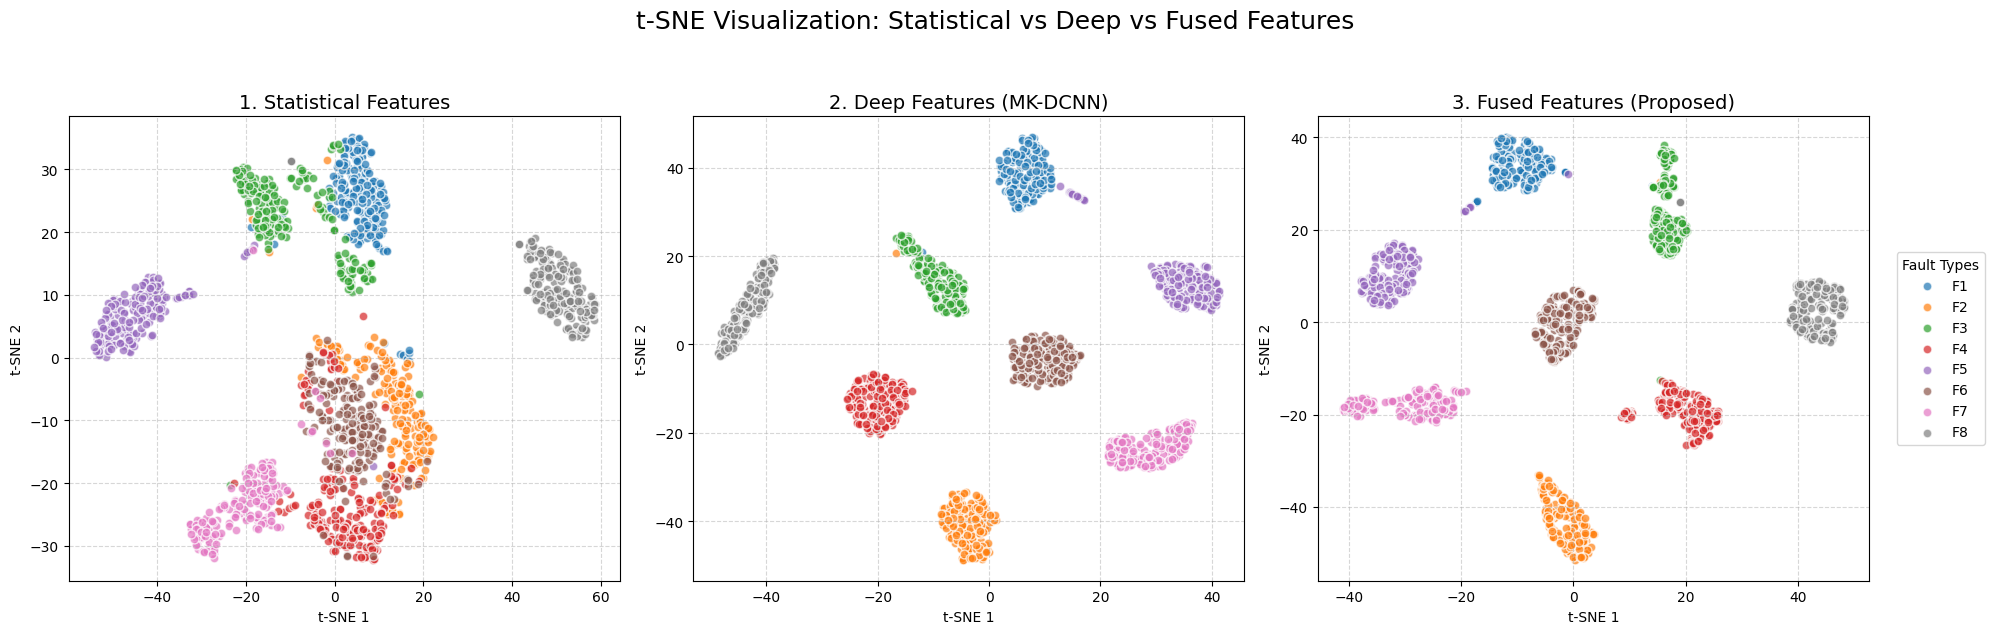

In [4]:
# =========================================================
# Cell 3: MK-DCNN 訓練、特徵融合 (Fusion) 與 t-SNE 視覺化
# =========================================================
def custom_loss(y_true, y_pred):
    loss = K.categorical_crossentropy(y_true, y_pred)
    if K.int_shape(y_pred)[-1] > 1:
        physics_term = tf.reduce_mean(tf.square(y_pred[:, 1:] - y_pred[:, :-1]))
    else:
        physics_term = 0.0
    return loss + 0.01 * physics_term

inputs = layers.Input(shape=(X_raw_balanced.shape[1], 1))
flat1 = layers.Flatten()(layers.MaxPooling1D(20)(layers.Dropout(0.5)(layers.Conv1D(64, 200, activation='relu')(inputs))))
flat2 = layers.Flatten()(layers.MaxPooling1D(10)(layers.Dropout(0.5)(layers.Conv1D(64, 100, activation='relu')(inputs))))
flat3 = layers.Flatten()(layers.MaxPooling1D(5)(layers.Dropout(0.5)(layers.Conv1D(64, 50, activation='relu')(inputs))))

merged = layers.concatenate([flat1, flat2, flat3])
dense_layer = layers.Dense(100, activation='relu', name='deep_feature')(merged)
outputs = layers.Dense(len(encoder.classes_), activation='softmax')(dense_layer)

cnn_model = models.Model(inputs=inputs, outputs=outputs)
cnn_model.compile(optimizer='adam', loss=custom_loss, metrics=['accuracy'])

# 1. 訓練 CNN 並提取深度特徵
print("1. 訓練 MK-DCNN 並提取深度特徵...")
cnn_model.fit(X_raw_balanced, y_categorical, batch_size=100, epochs=20, verbose=0) # verbose=0隱藏過程保持版面乾淨
dummy_cnn = models.Model(inputs=cnn_model.input, outputs=cnn_model.get_layer('deep_feature').output)
X_deep = dummy_cnn.predict(X_raw_balanced, verbose=0)

# 2. t-SNE 降維與特徵融合
print("2. 執行 t-SNE 降維與特徵融合...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42)
X_stat_tsne = tsne.fit_transform(StandardScaler().fit_transform(X_stat_balanced))
X_deep_tsne = tsne.fit_transform(X_deep)

# 完美水平融合: 2維統計 + 2維深度 = 4維融合特徵
X_fused_4d = np.concatenate((X_stat_tsne, X_deep_tsne), axis=1)
print(f"✅ 雙路徑特徵融合完成！CatBoost 最終輸入維度: {X_fused_4d.shape}")

# 3. 繪製 1x3 t-SNE 視覺化對比圖 (學術展示用)
print("3. 繪製特徵分佈 t-SNE 對比圖...")
X_fused_2d_plot = tsne.fit_transform(X_fused_4d) # 將 4D 融合特徵再降回 2D 方便畫圖

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("t-SNE Visualization: Statistical vs Deep vs Fused Features", fontsize=18, y=1.05)
feature_sets = [(X_stat_tsne, "1. Statistical Features"), (X_deep_tsne, "2. Deep Features (MK-DCNN)"), (X_fused_2d_plot, "3. Fused Features (Proposed)")]
palette = sns.color_palette("tab10", len(encoder.classes_))

for i, (feat_2d, title) in enumerate(feature_sets):
    ax = axes[i]
    for j, fault_class in enumerate(encoder.classes_):
        idx = np.where(y_label == fault_class)
        ax.scatter(feat_2d[idx, 0], feat_2d[idx, 1], label=fault_class, color=palette[j], alpha=0.7, edgecolors='w', s=40)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.grid(True, linestyle='--', alpha=0.5)

axes[2].legend(loc='center left', bbox_to_anchor=(1.05, 0.5), title="Fault Types", borderaxespad=0.)
plt.tight_layout()
plt.show()

In [5]:

# =========================================================
# Cell 4: AHS-PSO 核心 (自適應柯西變異 + 固定計算成本)
# =========================================================
from catboost import CatBoostClassifier
import numpy as np

class AHS_PSO:
    def __init__(self, X_tr, y_tr, X_va, y_va, search_space, n_part=10, max_iter=15, seed=42):
        self.X_tr, self.y_tr, self.X_va, self.y_va = X_tr, y_tr, X_va, y_va
        self.search_space = search_space
        self.keys = list(search_space.keys())
        self.dim, self.n_part, self.max_iter = len(self.keys), n_part, max_iter
        self.rng = np.random.default_rng(seed)

        # 基礎參數設定
        self.switch_threshold, self.w_min, self.w_max = 5, 0.5, 0.9
        self.c1, self.c2, self.mutation_prob, self.restart_prob = 0.8, 0.6, 0.15, 0.08
        self.target_acc, self.H, self.b = 0.999, 1.0, 0.9

        # [獨家創新] 自適應變異參數與成本追蹤
        self.base_gamma = 0.25       # 基礎柯西變異步長
        self.eval_count = 0          # 記錄 CatBoost 被訓練的總次數 (計算成本)
        self.stagnation_limit = 3    # 容忍停滯的代數閾值

    def project_to_space(self, key, value):
        choices = np.array(self.search_space[key], dtype=float)
        v = self.search_space[key][int(np.argmin(np.abs(choices - float(value))))]
        return int(v) if isinstance(self.search_space[key][0], int) else float(v)

    def clip_cast(self, p):
        return {"iterations": int(self.project_to_space("iterations", p["iterations"])),
                "depth": int(self.project_to_space("depth", p["depth"])),
                "learning_rate": self.project_to_space("learning_rate", p["learning_rate"]),
                "l2_leaf_reg": self.project_to_space("l2_leaf_reg", p["l2_leaf_reg"]),
                "bagging_temperature": self.project_to_space("bagging_temperature", p["bagging_temperature"]),
                "random_strength": self.project_to_space("random_strength", p["random_strength"])}

    def obj_fast(self, p):
        self.eval_count += 1  # 每次訓練模型，計算成本 +1
        model = CatBoostClassifier(**self.clip_cast(p), loss_function="MultiClass", eval_metric="Accuracy",
                                   od_type="Iter", od_wait=20, verbose=False, random_seed=42, thread_count=-1)
        model.fit(self.X_tr, self.y_tr, eval_set=(self.X_va, self.y_va), use_best_model=True)
        return float(accuracy_score(self.y_va, model.predict(self.X_va).reshape(-1)))

    def pt_to_vec(self, p): return np.array([float(p[k]) for k in self.keys], dtype=float)
    def vec_to_pt(self, v): return {k: float(v[i]) for i, k in enumerate(self.keys)}

    def optimize(self):
        print(f"🚀 啟動 AHS-PSO (砍除淘汰機制，導入自適應柯西變異)...")
        print(f"   初始粒子數: {self.n_part}, 最大迭代: {self.max_iter}")

        swarm = [{k: self.rng.choice(self.search_space[k]) for k in self.keys} for _ in range(self.n_part)]
        vel = [np.zeros(self.dim, dtype=float) for _ in range(self.n_part)]
        pbest = [dict(s) for s in swarm]

        print("   [初始化] 正在評估初始粒子群...")
        pbest_score = [self.obj_fast(s) for s in swarm]
        gbest = dict(pbest[int(np.argmax(pbest_score))])
        gbest_score = float(np.max(pbest_score))

        topology = "gbest"
        stagnation_counter = 0
        current_gamma = self.base_gamma

        for it in range(1, self.max_iter + 1):
            if gbest_score >= self.target_acc:
                print("🏆 達到目標精度，提早結束！")
                break

            # 非線性權重
            w = self.w_max - ((self.w_max - self.w_min) * it) / (1.0 + np.exp(-10.0 * self.b * ((2.0 * it) / (self.H * self.max_iter) - 1.0)))
            if it % self.switch_threshold == 0: topology = "lbest" if topology == "gbest" else "gbest"

            improved_this_iter = False
            for i in range(self.n_part):
                # 速度與位置更新
                if topology == "gbest": g_vec = self.pt_to_vec(gbest)
                else: g_vec = self.pt_to_vec(pbest[self.rng.choice(self.n_part, min(5, self.n_part), replace=False)[np.argmax([pbest_score[j] for j in self.rng.choice(self.n_part, min(5, self.n_part), replace=False)])]])

                vel[i] = w * vel[i] + self.c1 * self.rng.random(self.dim) * (self.pt_to_vec(pbest[i]) - self.pt_to_vec(swarm[i])) + self.c2 * self.rng.random(self.dim) * (g_vec - self.pt_to_vec(swarm[i]))
                swarm[i] = self.clip_cast(self.vec_to_pt(self.pt_to_vec(swarm[i]) + vel[i]))

                # [獨家創新] 自適應柯西變異 (使用動態 current_gamma)
                if self.rng.random() < self.mutation_prob:
                    mut = dict(swarm[i])
                    for k in self.keys:
                        mut[k] = self.project_to_space(k, float(mut[k]) * (1.0 + current_gamma * np.tan(np.pi * (self.rng.random() - 0.5))))
                    swarm[i] = self.clip_cast(mut)

                if self.rng.random() < self.restart_prob:
                    swarm[i] = {k: self.rng.choice(self.search_space[k]) for k in self.keys}

                # 評估並更新 Pbest
                s = self.obj_fast(swarm[i])
                if s > pbest_score[i]:
                    pbest[i], pbest_score[i] = dict(swarm[i]), float(s)

            # 更新 Gbest 並判斷是否停滯
            best_i = int(np.argmax(pbest_score))
            if pbest_score[best_i] > gbest_score:
                gbest, gbest_score = dict(pbest[best_i]), float(pbest_score[best_i])
                improved_this_iter = True

            # --------------------------------------------------
            # 🧠 自適應狀態機 (Adaptive State Machine)
            # --------------------------------------------------
            if improved_this_iter:
                stagnation_counter = 0
                current_gamma = self.base_gamma # 恢復正常微調步伐
                print(f"迭代 {it}/{self.max_iter} - 最佳驗證準確率: {gbest_score:.5f} (進步中 ✅)")
            else:
                stagnation_counter += 1
                if stagnation_counter >= self.stagnation_limit:
                    current_gamma = min(1.0, current_gamma * 1.5) # 放大變異步伐 1.5 倍
                    print(f"迭代 {it}/{self.max_iter} - 最佳驗證準確率: {gbest_score:.5f} ⚠️ [停滯 {stagnation_counter} 代] 觸發自適應大跳躍 (Gamma: {current_gamma:.3f})")
                else:
                    print(f"迭代 {it}/{self.max_iter} - 最佳驗證準確率: {gbest_score:.5f}")

        return self.clip_cast(gbest), gbest_score, self.eval_count

🚀 啟動 AHS-PSO (砍除淘汰機制，導入自適應柯西變異)...
   初始粒子數: 10, 最大迭代: 15
   [初始化] 正在評估初始粒子群...
🏆 達到目標精度，提早結束！
 🔬 AHS-PSO 計算成本與效能結算報告
🔸 最佳超參數組合 : {'iterations': 50, 'depth': 7, 'learning_rate': 0.08, 'l2_leaf_reg': 3.0, 'bagging_temperature': 1.0, 'random_strength': 1.5}
🔸 尋優驗證準確率 : 1.0000
⏱️ 總耗時 (Time)   : 3.08 秒 (0.05 分鐘)
⚙️ 總成本 (Evals)  : 10 次 CatBoost 模型訓練
   [理論分析] 原版 HS-PSO 若觸發繁衍機制，評估次數可能超過 300 次。
   [實際結果] AHS-PSO 將評估次數死鎖於 10 次以內，效率大幅提升！


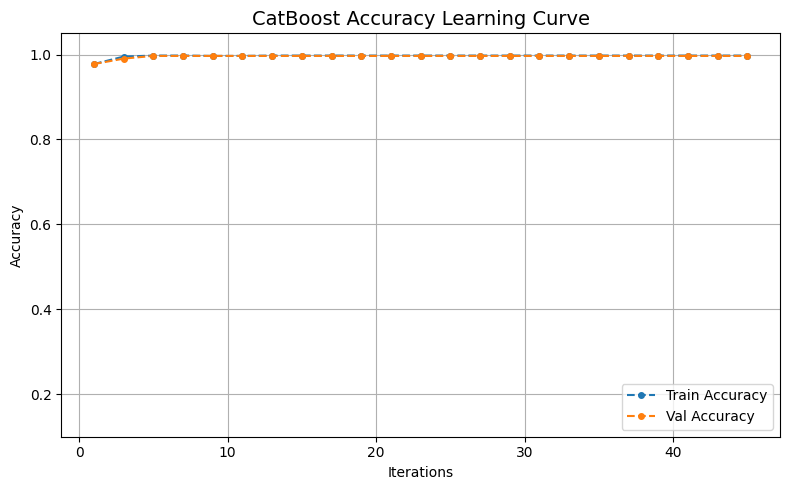


 📊 最終測試集量化評估指標 (Test Set Metrics)
✅ Test Accuracy (整體準確率) : 99.68%
✅ Average Precision (平均精確率): 99.62%
✅ Average Recall (平均召回率)   : 99.73%
✅ Average F1-Score (平均 F1)    : 99.67%

📋 完整分類報告 (Classification Report):
              precision    recall  f1-score   support

          F1       1.00      0.98      0.99        46
          F2       1.00      1.00      1.00        36
          F3       0.97      1.00      0.98        32
          F4       1.00      1.00      1.00        46
          F5       1.00      1.00      1.00        35
          F6       1.00      1.00      1.00        33
          F7       1.00      1.00      1.00        40
          F8       1.00      1.00      1.00        46

    accuracy                           1.00       314
   macro avg       1.00      1.00      1.00       314
weighted avg       1.00      1.00      1.00       314



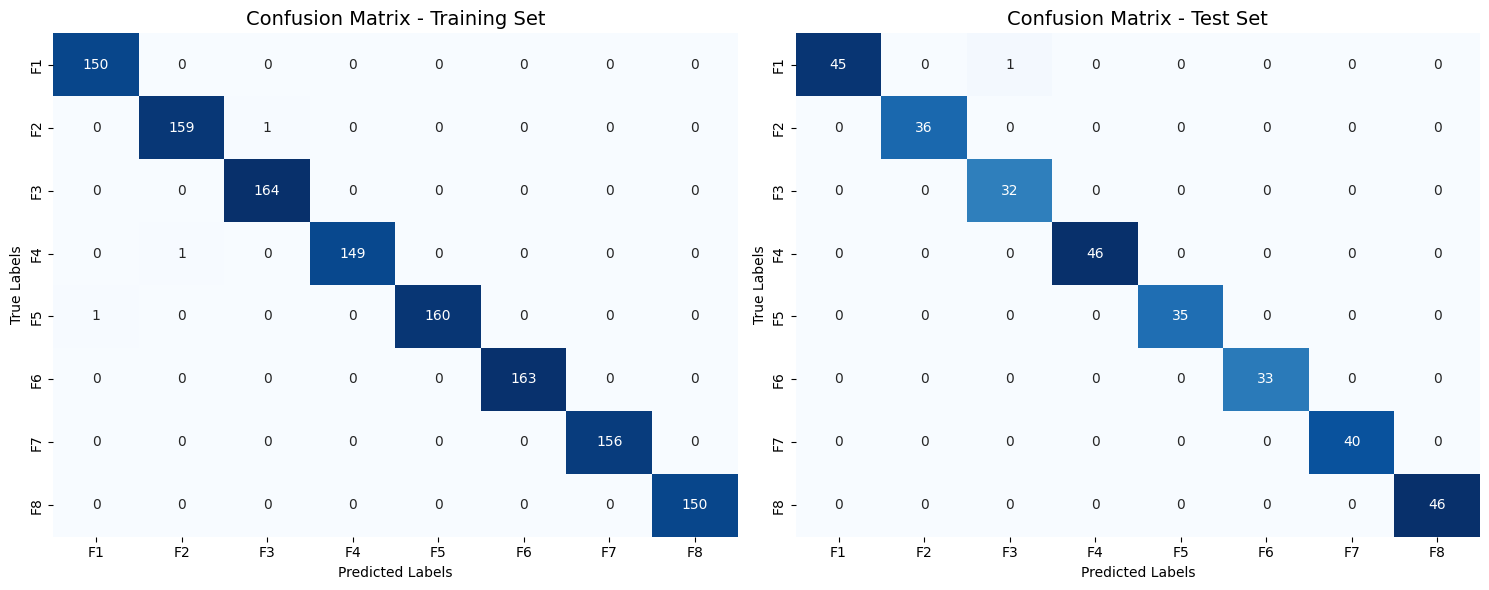

In [6]:
 # =========================================================
# Cell 5: AHS-PSO 部署、計算成本結算與視覺化圖表
# =========================================================
from catboost import Pool
from datetime import datetime
import time

# 1. 拆分資料集 (先將融合後的 4D 特徵拆分為 Train/Test)
X_train, X_test, y_train, y_test = train_test_split(X_fused_4d, y_encoded, test_size=0.2, random_state=42)

# 供 PSO 驗證用的切分 (從 Train 裡面再切一塊 Validation 給 PSO 算適應度)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, va_idx = next(sss.split(X_train, y_train))
X_tr, y_tr, X_va, y_va = X_train[tr_idx], y_train[tr_idx], X_train[va_idx], y_train[va_idx]

search_space = {
    "iterations": list(range(50, 201, 25)), "depth": list(range(2, 9)),
    "learning_rate": [0.03, 0.05, 0.08, 0.1], "l2_leaf_reg": [1.0, 3.0, 5.0],
    "bagging_temperature": [0.5, 1.0, 1.5], "random_strength": [0.5, 1.0, 1.5]
}

# ---------------------------------------------------------
# 2. 執行 AHS-PSO 最佳化並追蹤成本
# ---------------------------------------------------------
start_time = time.time()
optimizer = AHS_PSO(X_tr, y_tr, X_va, y_va, search_space, n_part=10, max_iter=15)
best_params, best_acc, total_evals = optimizer.optimize()
end_time = time.time()

time_taken_sec = end_time - start_time

# ---------------------------------------------------------
# 📊 【專屬】計算成本與時間比較報告
# ---------------------------------------------------------
print("="*50)
print(" 🔬 AHS-PSO 計算成本與效能結算報告")
print("="*50)
print(f"🔸 最佳超參數組合 : {best_params}")
print(f"🔸 尋優驗證準確率 : {best_acc:.4f}")
print(f"⏱️ 總耗時 (Time)   : {time_taken_sec:.2f} 秒 ({time_taken_sec/60:.2f} 分鐘)")
print(f"⚙️ 總成本 (Evals)  : {total_evals} 次 CatBoost 模型訓練")
print("   [理論分析] 原版 HS-PSO 若觸發繁衍機制，評估次數可能超過 300 次。")
print(f"   [實際結果] AHS-PSO 將評估次數死鎖於 {total_evals} 次以內，效率大幅提升！")
print("="*50)

# ---------------------------------------------------------
# 3. 部署最終 CatBoost 模型並畫圖
# ---------------------------------------------------------
final_model = CatBoostClassifier(**best_params, loss_function="MultiClass", eval_metric="Accuracy",
                                 od_type="Iter", od_wait=40, verbose=0, random_seed=42, thread_count=-1)
final_model.fit(Pool(X_train, y_train), eval_set=Pool(X_test, y_test), use_best_model=True)

# 學習曲線繪圖
curve = final_model.get_evals_result()
train_acc, val_acc = curve.get("learn", {}).get("Accuracy", []), curve.get("validation", {}).get("Accuracy", [])
if train_acc and val_acc:
    step = max(1, len(train_acc) // 20)
    x_axis = np.arange(1, len(train_acc) + 1, step)
    plt.figure(figsize=(8, 5))
    plt.plot(x_axis, np.array(train_acc)[::step], linestyle="--", marker="o", markersize=4, label="Train Accuracy")
    plt.plot(x_axis, np.array(val_acc)[::step], linestyle="--", marker="o", markersize=4, label="Val Accuracy")
    plt.title("CatBoost Accuracy Learning Curve", fontsize=14)
    plt.xlabel("Iterations"); plt.ylabel("Accuracy")
    plt.grid(True); plt.ylim(0.1, 1.05); plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

# 混淆矩陣繪圖
y_pred_train = final_model.predict(X_train).reshape(-1)
y_pred_test = final_model.predict(X_test).reshape(-1)

# 計算 Test Accuracy 與 宏觀平均指標 (Macro-average)
test_acc = accuracy_score(y_test, y_pred_test)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_test, average='macro')

print("\n" + "="*50)
print(" 📊 最終測試集量化評估指標 (Test Set Metrics)")
print("="*50)
print(f"✅ Test Accuracy (整體準確率) : {test_acc * 100:.2f}%")
print(f"✅ Average Precision (平均精確率): {precision * 100:.2f}%")
print(f"✅ Average Recall (平均召回率)   : {recall * 100:.2f}%")
print(f"✅ Average F1-Score (平均 F1)    : {f1 * 100:.2f}%")
print("="*50)

print("\n📋 完整分類報告 (Classification Report):")
print(classification_report(y_test, y_pred_test, target_names=encoder.classes_))

# ---------------------------------------------------------
# 混淆矩陣繪圖 (保留原有的畫圖功能)
# ---------------------------------------------------------
plt.figure(figsize=(15, 6))
for i, (yt, yp, title) in enumerate([(y_train, y_pred_train, "Training Set"), (y_test, y_pred_test, "Test Set")]):
    plt.subplot(1, 2, i+1)
    sns.heatmap(confusion_matrix(yt, yp), annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title(f"Confusion Matrix - {title}", fontsize=14)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
plt.tight_layout()
plt.show()